# Diabetes Prediction Using Artificial Neural Networks (ANN)

### Introduction
In this project, I built an Artificial Neural Network (ANN) using 
TensorFlow and Keras to predict whether a patient has diabetes based 
on medical measurements. The dataset used is the Pima Indians Diabetes 
dataset, which contains 768 patient records with 8 medical features 
such as glucose level, BMI, age, and insulin levels.

### Problem Statement
Diabetes is one of the fastest growing chronic diseases globally. 
Early and accurate prediction of diabetes can help doctors intervene 
early and significantly improve patient outcomes. The goal of this 
project is to build a deep learning model that can predict whether a 
patient is diabetic or not based on their medical measurements, 
providing a tool that could support clinical decision making.

### Objectives
- Load and explore the Pima Indians Diabetes dataset
- Preprocess the data by handling missing values and scaling features
- Build an ANN model using TensorFlow and Keras
- Train the model using dropout and early stopping to prevent overfitting
- Evaluate the model using accuracy, classification report, and 
  confusion matrix
- Visualize the training history
- Save and deploy the model as an interactive web application 
  using Streamlit

### Loading the dataset and EDA

In [3]:
!  pip install matplotlib seaborn tensorflow scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached pygments-2.19.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 801.7 kB/s eta 0:00:0000:0100:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 MB 242.2 kB/s eta 0:00:0000:0100:27
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 254.9 kB/s eta 0:00:0

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'matplotlib', 'seaborn', 'scikit-learn', 'tensorflow'])

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 266.1 kB/s  0:15:220:00:0100:20
   ━━━━━━━━━━━━━━━━━━━━━━

CompletedProcess(args=['pip', 'install', 'matplotlib', 'seaborn', 'scikit-learn', 'tensorflow'], returncode=0)

In [8]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [9]:
# Load the dataset
df = pd.read_csv('diabetes.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Basic info and statistics
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['Outcome'].value_counts())
print("\nBasic Statistics:")
df.describe()


Dataset Shape: (768, 9)

Column Names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


/var/folders/sg/34w1yqzx5tl21l1rqjjgjn200000gn/T/ipykernel_28534/1827935327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


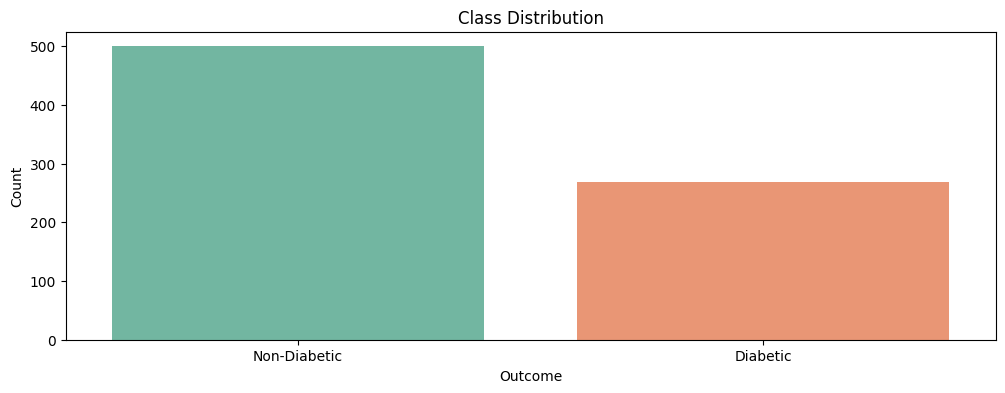

In [10]:
# Class distribution plot
plt.figure(figsize=(12,4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Class Distribution')
plt.xticks([0,1], ['Non-Diabetic', 'Diabetic'])
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()


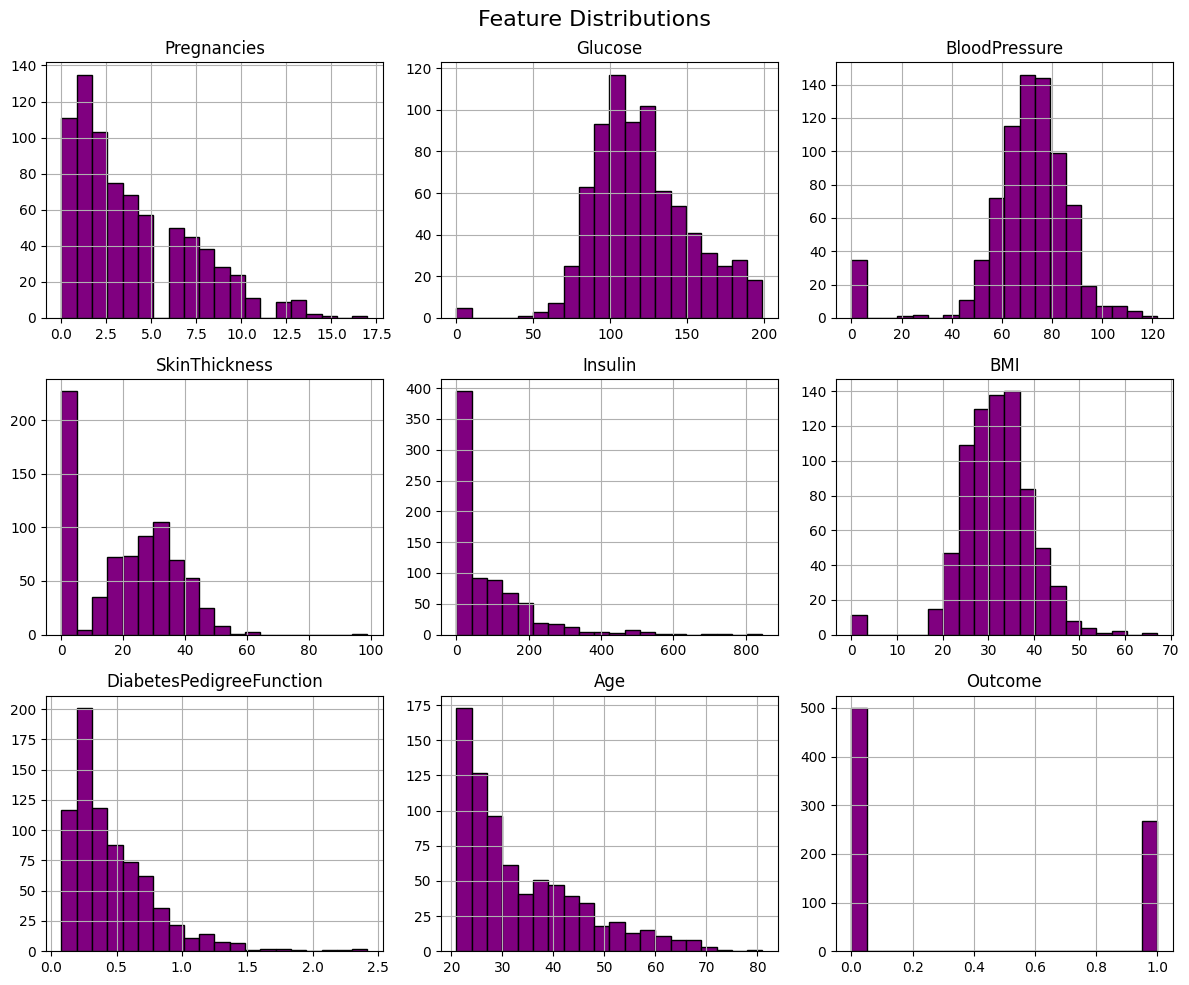

In [20]:
# Feature distributions
df.hist(figsize=(12,10), bins=20, color='Purple', edgecolor='Black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()



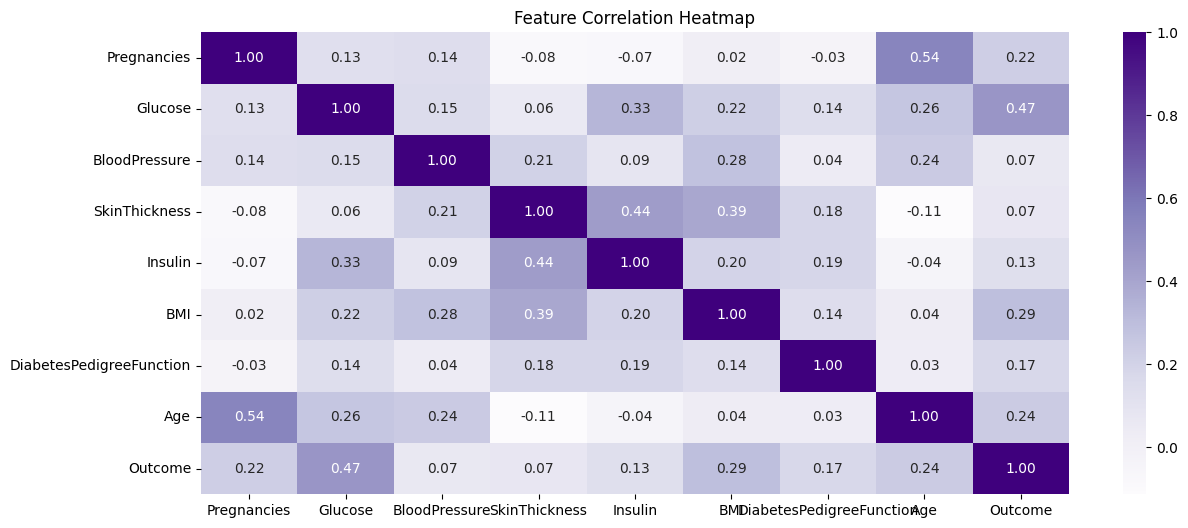

In [11]:
# Correlation heatmap
plt.figure(figsize=(14,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Purples')
plt.xticks(rotation=0)
plt.title('Feature Correlation Heatmap')
plt.show()


Key Findings
- The dataset contains **768 samples and 9 columns** (8 features + 1 target)
- **No missing values** across all columns
- Class distribution: **500 Non-Diabetic (0)** and **268 Diabetic (1)** 
  — the dataset is slightly imbalanced
- **Glucose** has the strongest positive correlation with the 
  target (0.47), making it the most influential feature
- **Age** and **Pregnancies** also show moderate positive correlations 
  with the outcome (0.24 and 0.22 respectively)
- **BMI** and **Insulin** show moderate relationships with 
  SkinThickness (0.39 and 0.44)

### Data Preprocessing

In [12]:
# Check for zero values that represent missing data
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero values per column:")
for col in zero_columns:
    zeros = (df[col] == 0).sum()
    print(f"{col}: {zeros} zeros")

Zero values per column:
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [13]:
# Replace zeros with median values
for col in zero_columns:
    df[col] = df[col].replace(0, df[col].median())

print("Zero values after replacement:")
for col in zero_columns:
    zeros = (df[col] == 0).sum()
    print(f"{col}: {zeros} zeros")

Zero values after replacement:
Glucose: 0 zeros
BloodPressure: 0 zeros
SkinThickness: 0 zeros
Insulin: 0 zeros
BMI: 0 zeros


In [14]:
# Define features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 614
Test samples: 154


**Handling Missing Values**

In this dataset, zero values in columns like Glucose, BloodPressure, 
SkinThickness, Insulin, and BMI represent missing data — it is 
medically impossible to have a value of zero for these measurements. 
These zero values were replaced with the median of each column to 
preserve the dataset size while handling missing data appropriately.

**Feature Scaling**

StandardScaler was applied to normalize all 8 features to the same 
scale, ensuring no single feature dominates the model during training.

**Train/Test Split**

The data was split 80/20 into training (614 samples) and 
test (154 samples) sets using a random state of 42 for reproducibility.

### Building the ANN Model

In [15]:
# Build the ANN model
model = Sequential([
    # Input layer
    Dense(64, activation='relu', input_shape=(8,)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Hidden layer 1
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Hidden layer 2
    Dense(16, activation='relu'),
    Dropout(0.2),
    
    # Output layer
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/Users/pc/miniforge3/envs/ds-env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 192 (768.00 B)

Building the ANN Model

I built a Sequential ANN model with the following architecture:

- **Input Layer:** 64 neurons with ReLU activation, BatchNormalization 
  and 30% Dropout
- **Hidden Layer 1:** 32 neurons with ReLU activation, BatchNormalization 
  and 30% Dropout
- **Hidden Layer 2:** 16 neurons with ReLU activation and 20% Dropout
- **Output Layer:** 1 neuron with Sigmoid activation — outputs a value 
  between 0 and 1 representing the probability of diabetes

The model has **3,585 total parameters** to learn during training.

**Compilation settings:**
- **Optimizer:** Adam — adapts the learning rate automatically
- **Loss Function:** Binary Cross Entropy — used for binary classification
- **Metric:** Accuracy

### Training the Model

In [16]:
# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete!")

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6191 - loss: 0.7393 - val_accuracy: 0.6504 - val_loss: 0.6526
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6680 - loss: 0.6661 - val_accuracy: 0.7236 - val_loss: 0.6271
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7088 - loss: 0.5623 - val_accuracy: 0.7480 - val_loss: 0.6051
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7149 - loss: 0.5478 - val_accuracy: 0.7561 - val_loss: 0.5861
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7434 - loss: 0.5134 - val_accuracy: 0.7398 - val_loss: 0.5720
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7251 - loss: 0.5458 - val_accuracy: 0.7480 - val_loss: 0.5584
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7271 - loss: 0.5341 - val_accuracy: 0.7398 - val_loss: 0.5445
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7128 - loss: 0.5462 - val_accuracy: 0.7398 - v

Training the Model

The model was trained for a maximum of 100 epochs with a batch size 
of 32 and a 20% validation split. Early stopping was applied with a 
patience of 10 epochs to prevent overfitting.

The model stopped early at **epoch 42** — meaning the validation loss 
stopped improving after that point. The final training accuracy was 
approximately **78.6%** and validation accuracy was **77.2%**, showing 
the model is learning well without significant overfitting.

### Model Evaluation

Test Loss: 0.5284
Test Accuracy: 0.7273
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.81      0.75      0.78        99
    Diabetic       0.60      0.69      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



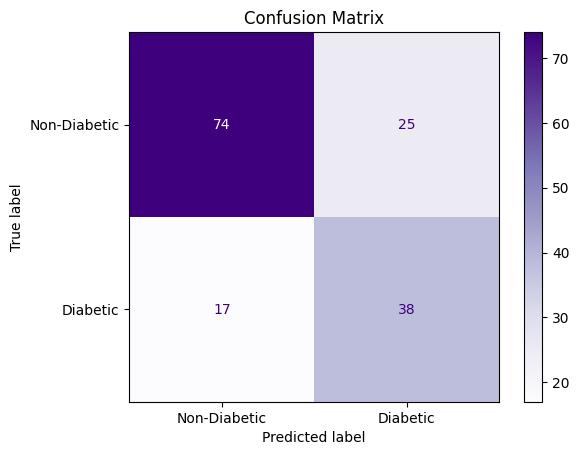

In [17]:
# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(cmap='Purples')
plt.title('Confusion Matrix')
plt.show()



The model achieved a **test accuracy of 72.73%** on 154 unseen samples.

**Confusion Matrix Results:**
- 74 correctly predicted as Non-Diabetic
- 38 correctly predicted as Diabetic
- 25 False Positives — predicted Diabetic but actually Non-Diabetic
- 17 False Negatives — predicted Non-Diabetic but actually Diabetic

**Classification Report:**
The model performs better on Non-Diabetic cases (F1=0.78) than 
Diabetic cases (F1=0.64). This is due to the class imbalance in 
the dataset — there are more Non-Diabetic samples than Diabetic ones, 
causing the model to be better at identifying the majority class.

In a medical context, the 17 False Negatives are the most critical 
errors — these are diabetic patients the model failed to identify.

### Visualizing training History

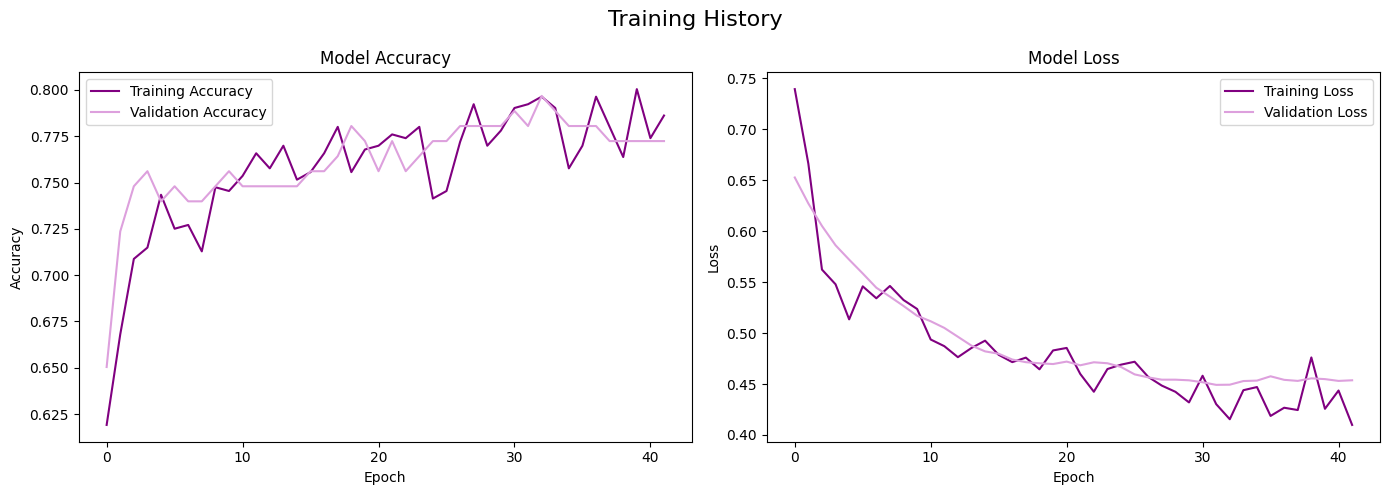

In [18]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='purple')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='plum')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', color='purple')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='plum')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Training History', fontsize=16)
plt.tight_layout()
plt.show()


The training history plots show a healthy learning curve:

- **Accuracy** steadily increased from ~62% to ~77-80% for both 
  training and validation sets
- **Loss** steadily decreased from ~0.75 to ~0.45 for both sets
- The training and validation lines stay close together throughout, 
  confirming the model is not overfitting
- Early stopping triggered at epoch 42 when validation loss 
  stopped improving

### Saving the Model

In [19]:
import pickle
from sklearn.preprocessing import StandardScaler

# Save the model
model.save('diabetes_model.h5')
print("Model saved as diabetes_model.h5")

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved as scaler.pkl")

Model saved as diabetes_model.h5
Scaler saved as scaler.pkl
